C:\Users\Atharv Bachawar\AppData\Local\Temp\ipykernel_15612\3368950960.py:8: DtypeWarning: Columns (3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  query_df = pd.read_csv('query.bed.gz', sep='\t', header=None, compression='gzip')


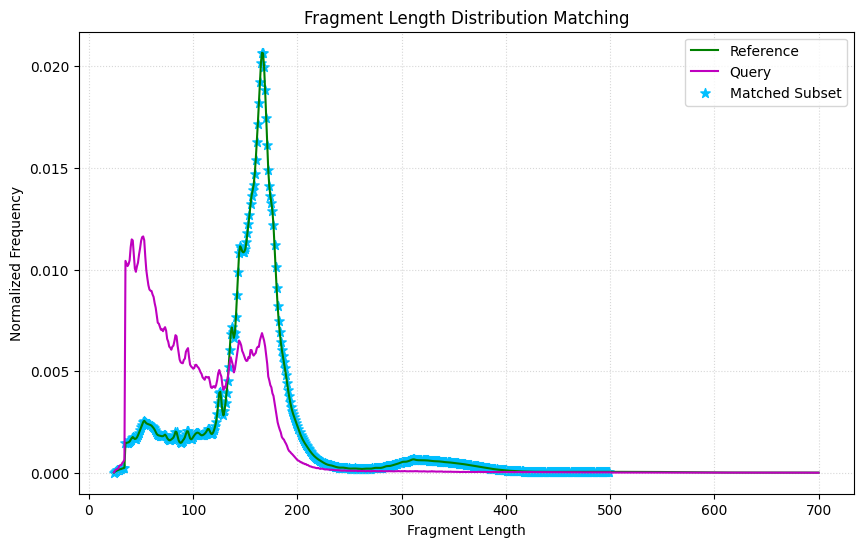

In [2]:

import gzip
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
ref_df = pd.read_csv('reference.hist', sep='\t', header=None)
query_df = pd.read_csv('query.bed.gz', sep='\t', header=None, compression='gzip')
query_lengths = query_df.iloc[:, 2] - query_df.iloc[:, 1] 
query_counts = pd.Series(query_lengths).value_counts().sort_index()
query_normalized = query_counts / query_counts.sum()
bin_edges = np.arange(0, 510, 10)
bin_labels = [f"{i}-{i+9}bp" for i in range(0, 500, 10)]
ref_df['size_bin'] = pd.cut(ref_df[0], bins=bin_edges, labels=bin_labels, right=False)
query_df['fragment_length'] = query_df[2] - query_df[1]
query_df['size_bin'] = pd.cut(query_df['fragment_length'], bins=bin_edges, labels=bin_labels, right=False)
ref_bin_counts = ref_df['size_bin'].value_counts().sort_index()
query_bin_counts = query_df['size_bin'].value_counts().sort_index()


matched_fragments = []
for bin_name in bin_labels:
    ref_count = ref_bin_counts.get(bin_name, 0)
    query_count = query_bin_counts.get(bin_name, 0)
    
    match_size = min(ref_count, query_count)
    
    if match_size > 0:
        bin_fragments = ref_df[ref_df['size_bin'] == bin_name]
        matched = bin_fragments.sample(n=match_size, random_state=42)
        matched_fragments.append(matched)


final_matched_set = pd.concat(matched_fragments).sort_values(0)
plt.figure(figsize=(10, 6))
plt.plot(ref_df[0], ref_df[1], 'g-', label='Reference')
plt.plot(query_counts.index, query_normalized, 'm-', label='Query')
plt.scatter(final_matched_set[0], final_matched_set[1], 
           c='deepskyblue', marker='*', s=50, label='Matched Subset')
plt.legend()
plt.xlabel('Fragment Length')
plt.ylabel('Normalized Frequency')
plt.title('Fragment Length Distribution Matching')
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()